# Exploratory Data Analysis

This notebook explores the combined Near-Earth Object dataset before machine learning.

The analysis will examine:

1. Class balance
2. Numerical feature distributions
3. Differences between hazardous and non-hazardous objects
4. Relationships between variables
5. Supplementary-data coverage

## Data quality considerations

Data quality was considered using the UK Government Data Quality Framework, which identifies six core dimensions: completeness, uniqueness, consistency, timeliness, validity and accuracy.

For this project, particular attention was given to completeness, uniqueness, validity and consistency. Missing values and supplementary-data coverage were assessed for completeness; duplicate records and identifier uniqueness were checked; data types and numerical distributions were reviewed for validity; and identifier matching and row counts before and after integration were used to assess consistency.

Accuracy could not be independently verified from the datasets alone, while timeliness was less critical because the project analyses historical NEO observations. These limitations were therefore considered when interpreting the results.

In [1]:
# Import pandas for working with the dataset and matplotlib for creating the EDA visualisations
import pandas as pd
import matplotlib.pyplot as plt

# Load the combined dataset created in the data engineering notebook
# This contains the primary NEO data along with any matched supplementary orbital data
data = pd.read_csv("combined_neo_dataset.csv")


In [2]:
# Check the overall size of the combined dataset before starting the analysis
print("Dataset shape:", data.shape)

# Preview the first few rows to make sure the data has loaded as expected
data.head()


Dataset shape: (338171, 17)


,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous,spkid,e,a,q,i,per,class,matched_supplementary
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False,2162117.0,0.344834,0.932486,0.610933,26.795548,328.898516,ATE,True
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True,2349507.0,0.581509,1.167263,0.488489,13.576888,460.629169,APO,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False,2455415.0,0.191237,1.281544,1.036465,3.842210,529.905950,AMO,True
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False,3132126.0,0.343319,1.072262,0.704134,32.951327,405.554991,APO,True
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False,3557844.0,0.275227,0.839730,0.608614,25.066956,281.065906,ATE,True


## Hazardous class distribution

The target variable is inspected to determine whether hazardous and non-hazardous observations are evenly represented. This is important because accuracy can be misleading when one class is much more common.

In [3]:
# Count the number of hazardous and non-hazardous records in the target variable
# This gives an initial view of whether the classes are balanced
data["is_hazardous"].value_counts()


is_hazardous
False    295009
True      43162
Name: count, dtype: int64

In [4]:
# Calculate the percentage of records in each hazardous class
# Normalising the counts makes the class imbalance easier to interpret than raw totals alone
hazard_percentages = (
    data["is_hazardous"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

hazard_percentages


is_hazardous
False    87.24
True     12.76
Name: proportion, dtype: float64

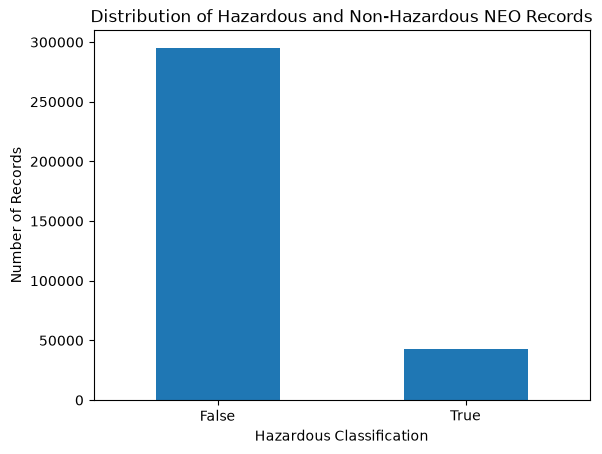

In [5]:
# Store the class counts so they can be plotted
class_counts = data["is_hazardous"].value_counts()

# Plot the number of records in each class to make the imbalance visually clear
class_counts.plot(kind="bar")

# Add clear labels so the chart can be interpreted without referring back to the code
plt.title("Distribution of Hazardous and Non-Hazardous NEO Records")
plt.xlabel("Hazardous Classification")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()


The dataset is imbalanced, with hazardous records representing 12.76% of observations. Accuracy alone may therefore give a misleading view of model performance. Recall will be prioritised because false negatives would represent hazardous objects being incorrectly classified as non-hazardous.

In [6]:
# Select the main numerical variables that may be useful for later modelling
# This includes the primary physical/approach features and the supplementary orbital features
numerical_features = [
    "absolute_magnitude",
    "estimated_diameter_min",
    "estimated_diameter_max",
    "relative_velocity",
    "miss_distance",
    "e",
    "a",
    "q",
    "i",
    "per"
]

# Review summary statistics such as the mean, median range and spread of each numerical feature
# This helps identify differences in scale, possible skew and unusually large values
data[numerical_features].describe()


,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance,e,a,q,i,per
count,338171.000000,338171.000000,338171.000000,338171.000000,3.381710e+05,241900.000000,241900.000000,241900.000000,241900.000000,2.419000e+05
mean,22.932525,0.157812,0.352878,51060.017994,4.153547e+07,0.377791,1.330099,0.784261,13.272555,5.957273e+02
std,2.911216,0.313885,0.701869,26399.922830,2.077411e+07,0.182413,0.863269,0.246817,10.815922,4.928733e+03
min,9.250000,0.000511,0.001143,203.346433,6.745533e+03,0.002846,0.555418,0.070511,0.013518,1.511918e+02
25%,20.740000,0.025384,0.056760,30710.626399,2.494495e+07,0.236628,0.975104,0.598792,5.167881,3.517020e+02
50%,22.800000,0.073207,0.163697,47557.046397,4.332724e+07,0.358685,1.190514,0.795312,10.190733,4.744604e+02
75%,25.100000,0.189041,0.422708,66673.223798,5.933961e+07,0.501154,1.544767,0.977242,19.082777,7.012822e+02
max,33.580000,37.545248,83.953727,291781.106613,7.479865e+07,0.996476,352.628376,1.681764,165.541000,2.418657e+06


## Comparison by hazardous classification

Median values are compared because several numerical features contain extreme values and appear skewed.

In [7]:
# Focus first on the main physical and close-approach features from the primary dataset
features_to_compare = [
    "absolute_magnitude",
    "estimated_diameter_max",
    "relative_velocity",
    "miss_distance"
]

# Compare median values between hazardous and non-hazardous records
# The median is used because it is less affected by extreme values than the mean
data.groupby("is_hazardous")[features_to_compare].median()


,absolute_magnitude,estimated_diameter_max,relative_velocity,miss_distance
is_hazardous,,,,
False,23.39,0.124750,45692.856505,4.344197e+07
True,20.62,0.446725,59967.023231,4.254752e+07


In [8]:
# Select the supplementary orbital variables for a separate comparison
orbital_features = [
    "e",
    "a",
    "q",
    "i",
    "per"
]

# Compare median orbital characteristics between the two hazardous classes
# Records without a supplementary match contain missing values here and are ignored by the median calculation
data.groupby("is_hazardous")[orbital_features].median()


,e,a,q,i,per
is_hazardous,,,,,
False,0.342459,1.180777,0.808630,10.186854,468.651766
True,0.464776,1.241873,0.707933,10.300004,505.492138


### Initial findings

Hazardous NEO records were typically brighter, larger and faster than non-hazardous records. They also had higher median eccentricity and lower perihelion distance. Median miss distance and inclination showed smaller differences between classes.

Orbital comparisons apply only to records matched with the supplementary dataset.

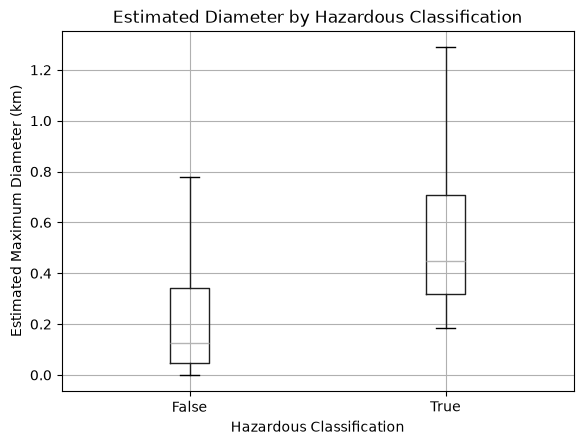

In [9]:
# Compare the estimated maximum diameter distributions for hazardous and non-hazardous records
# Outliers are hidden so the main difference between the two distributions is easier to see
data.boxplot(
    column="estimated_diameter_max",
    by="is_hazardous",
    showfliers=False
)

# Remove pandas' automatic group-by subtitle and add clearer chart labels
plt.title("Estimated Diameter by Hazardous Classification")
plt.suptitle("")
plt.xlabel("Hazardous Classification")
plt.ylabel("Estimated Maximum Diameter (km)")
plt.show()


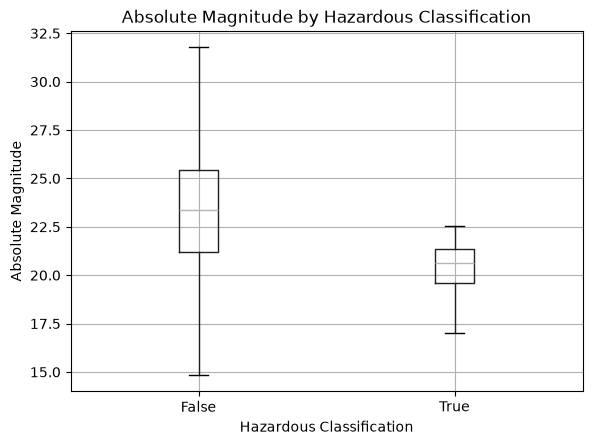

In [10]:
# Compare absolute magnitude between hazardous and non-hazardous records
# Again, extreme values are hidden from the plot so the central distributions are easier to compare
data.boxplot(
    column="absolute_magnitude",
    by="is_hazardous",
    showfliers=False
)

plt.title("Absolute Magnitude by Hazardous Classification")
plt.suptitle("")
plt.xlabel("Hazardous Classification")
plt.ylabel("Absolute Magnitude")
plt.show()


### Visual interpretation

Hazardous NEO records generally had lower absolute magnitude values and larger estimated diameters than non-hazardous records. The differences were visible in both the median comparisons and the boxplots, suggesting that brightness and estimated size may be important predictors of hazardous classification.

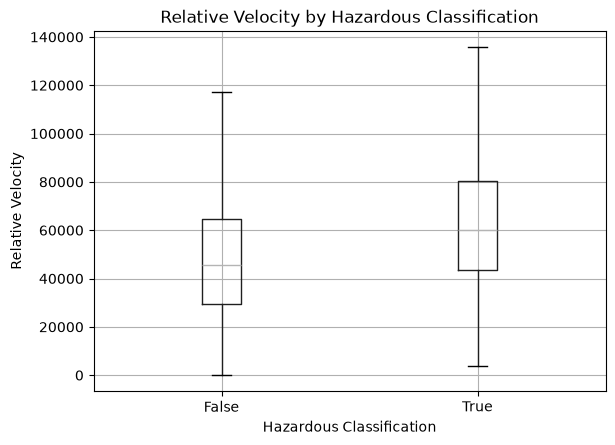

In [11]:
# Compare relative velocity distributions between the two hazardous classes
# Hiding the outliers keeps the main spread and median differences visible
data.boxplot(
    column="relative_velocity",
    by="is_hazardous",
    showfliers=False
)

plt.title("Relative Velocity by Hazardous Classification")
plt.suptitle("")
plt.xlabel("Hazardous Classification")
plt.ylabel("Relative Velocity")
plt.show()


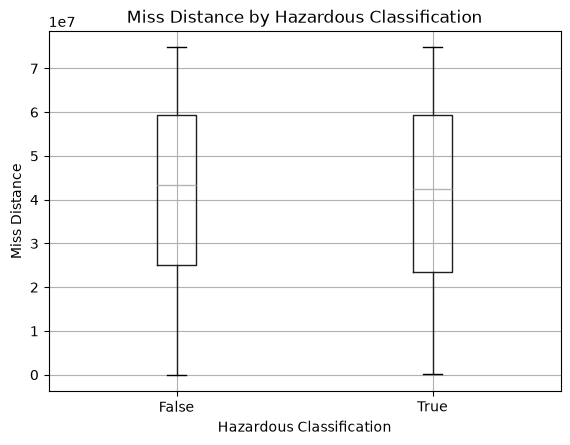

In [12]:
# Compare miss distance between hazardous and non-hazardous records
# This helps assess whether miss distance appears to separate the two classes on its own
data.boxplot(
    column="miss_distance",
    by="is_hazardous",
    showfliers=False
)

plt.title("Miss Distance by Hazardous Classification")
plt.suptitle("")
plt.xlabel("Hazardous Classification")
plt.ylabel("Miss Distance")
plt.show()


### Further visual findings

Relative velocity was generally higher for hazardous NEO records, although the two groups still overlapped. Miss distance showed very similar distributions for hazardous and non-hazardous records, suggesting it may be less useful as a standalone predictor.

In [13]:
# Use the numerical features to check how strongly they are related to one another
correlation_features = [
    "absolute_magnitude",
    "estimated_diameter_min",
    "estimated_diameter_max",
    "relative_velocity",
    "miss_distance",
    "e",
    "a",
    "q",
    "i",
    "per"
]

# Calculate a Pearson correlation matrix for the selected numerical variables
# Missing supplementary values are handled pairwise by pandas when each correlation is calculated
correlation_matrix = data[correlation_features].corr()

# Round the values to make the matrix easier to read in the notebook
correlation_matrix.round(2)


,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance,e,a,q,i,per
absolute_magnitude,1.00,-0.59,-0.59,-0.35,-0.21,-0.42,-0.18,0.07,-0.46,-0.02
estimated_diameter_min,-0.59,1.00,1.00,0.22,0.11,0.24,0.11,-0.04,0.27,0.01
estimated_diameter_max,-0.59,1.00,1.00,0.22,0.11,0.24,0.11,-0.04,0.27,0.01
relative_velocity,-0.35,0.22,0.22,1.00,0.32,0.56,0.05,-0.50,0.46,0.02
miss_distance,-0.21,0.11,0.11,0.32,1.00,0.03,-0.01,-0.01,0.18,-0.00
e,-0.42,0.24,0.24,0.56,0.03,1.00,0.28,-0.51,0.07,0.04
a,-0.18,0.11,0.11,0.05,-0.01,0.28,1.00,0.26,0.03,0.86
q,0.07,-0.04,-0.04,-0.50,-0.01,-0.51,0.26,1.00,-0.03,0.03
i,-0.46,0.27,0.27,0.46,0.18,0.07,0.03,-0.03,1.00,0.02
per,-0.02,0.01,0.01,0.02,-0.00,0.04,0.86,0.03,0.02,1.00


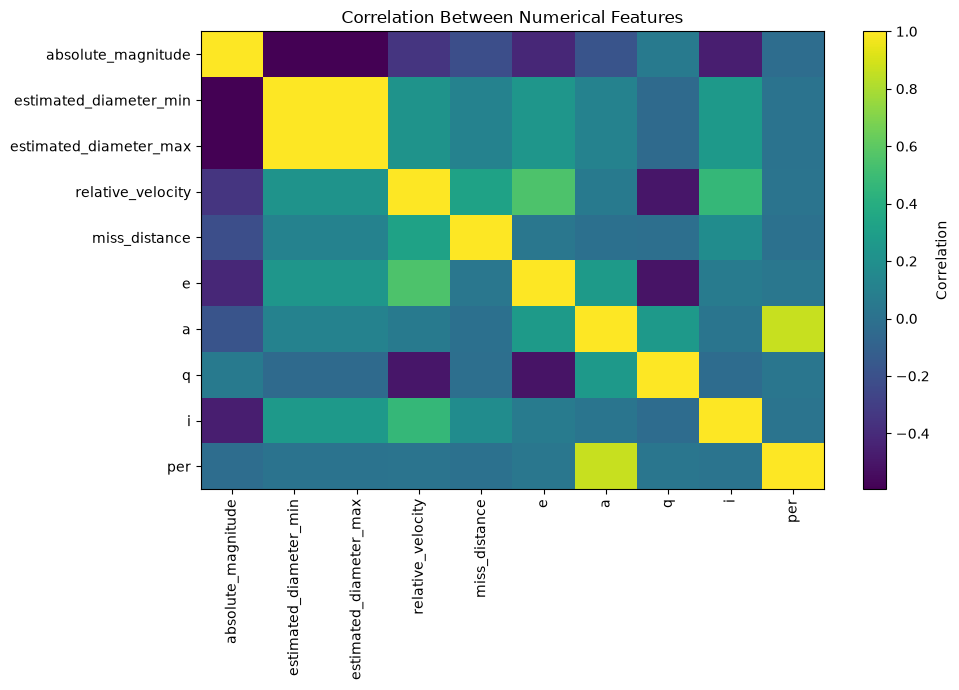

In [14]:
# Create a larger figure so all feature names remain readable
plt.figure(figsize=(10, 7))

# Display the correlation matrix as a heatmap-style image
plt.imshow(correlation_matrix, aspect="auto")

# Add a scale showing what the displayed correlation values represent
plt.colorbar(label="Correlation")

# Use the feature names as labels on both axes
plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=90
)
plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

plt.title("Correlation Between Numerical Features")

# Adjust spacing so the rotated x-axis labels are not cut off
plt.tight_layout()
plt.show()


### Correlation findings

The minimum and maximum diameter estimates were perfectly correlated, indicating that they contained almost identical information. The minimum estimate will therefore be excluded from modelling to reduce duplication.

Semi-major axis and orbital period also had a strong positive correlation. Both were retained for modelling, but this relationship was noted as a potential source of overlapping information and is considered as a limitation.

In [15]:
# Count the number of records in each supplementary orbit class
# Missing values are not included, so these counts relate only to records matched with supplementary data
data["class"].value_counts()


class
APO    128730
ATE     66619
AMO     45379
IEO      1066
MCA       102
MBA         4
Name: count, dtype: int64

In [16]:
# Compare orbit class composition between hazardous and non-hazardous records
# Normalising by columns converts the counts into percentages within each hazardous class
orbit_class_comparison = pd.crosstab(
    data["class"],
    data["is_hazardous"],
    normalize="columns"
) * 100

# Round the percentages to make the comparison easier to read
orbit_class_comparison.round(2)


is_hazardous,False,True
class,,
AMO,21.58,3.20
APO,49.74,72.37
ATE,28.28,23.44
IEO,0.34,0.98
MBA,0.00,0.00
MCA,0.05,0.01


### Orbit class findings

APO was the most common orbit class and represented a much larger proportion of hazardous records than non-hazardous records. AMO objects were more common among non-hazardous records. This suggests orbit class may provide useful information for classification.

These results apply only to records matched with the supplementary dataset.

## EDA summary

The dataset was imbalanced, with hazardous records representing 12.76% of observations. This means accuracy alone may overstate model performance, so recall will be prioritised during evaluation.

Hazardous records were typically larger, brighter and faster. They also had higher eccentricity, lower perihelion distance and were more commonly classified as APO objects.

Miss distance and inclination showed smaller differences between the two classes. The two diameter estimates were perfectly correlated, so only the maximum diameter estimate will be used for modelling.

Supplementary orbital features were available for 241,900 records. Results using these features must therefore be interpreted as applying to the matched subset rather than the complete primary dataset.